# NB08 - Aprendizaje sensible al costo y clases desbalanceadas con Titanic

Titanic ya tiene desbalance moderado. Para estudiar el problema con claridad, construiremos un train artificialmente más desbalanceado y compararemos tres respuestas: pesos de clase, ajuste de umbral y SMOTE.


In [1]:
%matplotlib inline

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks_2":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data" / "processed"

pd.set_option("display.max_columns", 80)
pd.set_option("display.precision", 4)

from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    PrecisionRecallDisplay,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

from src.titanic_utils import RANDOM_STATE, load_processed_splits, set_plot_style

set_plot_style()
data = load_processed_splits(DATA_DIR)
X_train = data["X_train_processed"]
X_test = data["X_test_processed"]
y_train = data["y_train"]
y_test = data["y_test"]


## 1. Desbalance artificial

Reducimos la clase positiva en train con `frac=0.35`, conservando todos los fallecidos. Esto crea una situación donde accuracy puede ocultar errores sobre supervivientes. El test se mantiene intacto para evaluar contra la distribución original.


In [2]:
survivor_idx = y_train[y_train == 1].sample(frac=0.35, random_state=RANDOM_STATE).index
died_idx = y_train[y_train == 0].index
keep_idx = died_idx.union(survivor_idx).sort_values()

X_train_imb = X_train.loc[keep_idx].reset_index(drop=True)
y_train_imb = y_train.loc[keep_idx].reset_index(drop=True)

display(
    pd.DataFrame(
        {
            "train_original": y_train.value_counts(normalize=True).sort_index(),
            "train_desbalanceado": y_train_imb.value_counts(normalize=True).sort_index(),
            "test_intacto": y_test.value_counts(normalize=True).sort_index(),
        }
    ).rename(index={0: "fallecido", 1: "sobreviviente"})
)


,train_original,train_desbalanceado,test_intacto
survived,,,
fallecido,0.6164,0.8205,0.6157
sobreviviente,0.3836,0.1795,0.3843


## 2. Modelo ingenuo y problema del accuracy

El modelo ingenuo usa `class_weight=None` y umbral 0.5. `C=1.0` mantiene regularización L2 moderada; el objetivo aquí no es optimizar AUC, sino ver cómo cambian las decisiones.


In [3]:
def evaluate_predictions(name, y_true, y_prob, threshold=0.5):
    pred = (y_prob >= threshold).astype(int)
    return {
        "modelo": name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred),
        "f1": f1_score(y_true, pred),
        "auc": roc_auc_score(y_true, y_prob),
    }


naive_model = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=1000,
    random_state=RANDOM_STATE,
)
naive_model.fit(X_train_imb, y_train_imb)
naive_prob = naive_model.predict_proba(X_test)[:, 1]

results = [evaluate_predictions("ingenuo", y_test, naive_prob, threshold=0.5)]
display(pd.DataFrame(results))


,modelo,threshold,accuracy,balanced_accuracy,precision,recall,f1,auc
0,ingenuo,0.5,0.7836,0.7276,0.9091,0.4854,0.6329,0.8549


## 3. Solución 1: ponderación de clases

`class_weight="balanced"` asigna pesos inversamente proporcionales a la frecuencia de clase en train. Es una forma simple de cambiar la función de pérdida sin duplicar observaciones.


In [4]:
weighted_model = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE,
)
weighted_model.fit(X_train_imb, y_train_imb)
weighted_prob = weighted_model.predict_proba(X_test)[:, 1]

results.append(evaluate_predictions("class_weight_balanced", y_test, weighted_prob, threshold=0.5))
display(pd.DataFrame(results))


,modelo,threshold,accuracy,balanced_accuracy,precision,recall,f1,auc
0,ingenuo,0.5,0.7836,0.7276,0.9091,0.4854,0.6329,0.8549
1,class_weight_balanced,0.5,0.7873,0.7908,0.6917,0.8058,0.7444,0.8546


## 4. Solución 2: ajuste de umbral

Si el costo de predecir "falleció" para alguien que sobrevivió (`FN`) es cinco veces el costo de un falso positivo, el umbral de decisión sensible al costo es `C_FP / (C_FP + C_FN) = 1 / 6`. Este umbral predice supervivencia con mayor facilidad.


In [5]:
cost_fp = 1
cost_fn = 5
cost_sensitive_threshold = cost_fp / (cost_fp + cost_fn)

results.append(
    evaluate_predictions(
        "ingenuo_umbral_costo",
        y_test,
        naive_prob,
        threshold=cost_sensitive_threshold,
    )
)
display(pd.DataFrame(results))


,modelo,threshold,accuracy,balanced_accuracy,precision,recall,f1,auc
0,ingenuo,0.5000,0.7836,0.7276,0.9091,0.4854,0.6329,0.8549
1,class_weight_balanced,0.5000,0.7873,0.7908,0.6917,0.8058,0.7444,0.8546
2,ingenuo_umbral_costo,0.1667,0.7836,0.7896,0.6829,0.8155,0.7434,0.8549


## 5. Solución 3: SMOTE

SMOTE crea ejemplos sintéticos de la clase minoritaria interpolando entre vecinos. Usamos `sampling_strategy=0.75` para no forzar balance perfecto y `k_neighbors=5`, el valor clásico cuando hay suficientes ejemplos minoritarios.


In [6]:
smote = SMOTE(
    sampling_strategy=0.75,
    k_neighbors=5,
    random_state=RANDOM_STATE,
)
X_smote, y_smote = smote.fit_resample(X_train_imb, y_train_imb)

smote_model = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=1000,
    random_state=RANDOM_STATE,
)
smote_model.fit(X_smote, y_smote)
smote_prob = smote_model.predict_proba(X_test)[:, 1]

results.append(evaluate_predictions("smote", y_test, smote_prob, threshold=0.5))

print("Distribución después de SMOTE:")
display(pd.Series(y_smote).value_counts(normalize=True).sort_index().rename(index={0: "fallecido", 1: "sobreviviente"}))
display(pd.DataFrame(results))


Distribución después de SMOTE:


survived
fallecido        0.5714
sobreviviente    0.4286
Name: proportion, dtype: float64

,modelo,threshold,accuracy,balanced_accuracy,precision,recall,f1,auc
0,ingenuo,0.5000,0.7836,0.7276,0.9091,0.4854,0.6329,0.8549
1,class_weight_balanced,0.5000,0.7873,0.7908,0.6917,0.8058,0.7444,0.8546
2,ingenuo_umbral_costo,0.1667,0.7836,0.7896,0.6829,0.8155,0.7434,0.8549
3,smote,0.5000,0.8097,0.8017,0.7453,0.7670,0.7560,0.8535


## 6. Comparación con curvas PR

Las curvas precision-recall muestran el intercambio completo para la clase positiva. Son más informativas que accuracy cuando nos importa recuperar supervivientes bajo desbalance.


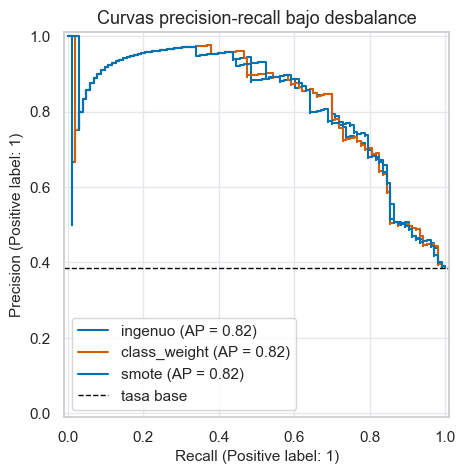

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, prob in [
    ("ingenuo", naive_prob),
    ("class_weight", weighted_prob),
    ("smote", smote_prob),
]:
    PrecisionRecallDisplay.from_predictions(y_test, prob, name=name, ax=ax)
ax.axhline(y_test.mean(), linestyle="--", color="black", linewidth=1, label="tasa base")
ax.set_title("Curvas precision-recall bajo desbalance")
ax.legend()
plt.show()


## Resumen y conexión con la literatura

El desbalance no se arregla con una sola receta. Pesos de clase modifican la pérdida, umbrales modifican la decisión y SMOTE modifica los datos de entrenamiento. La elección depende del costo de los errores y del objetivo operativo, en línea con Elkan, Chawla et al. y He y Garcia.
